<a href="https://colab.research.google.com/github/malehzja/lis4693/blob/main/lab-7/Lab_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab-7 Sentiment Analysis

## Objectives

- Load lab-4 dataset file from GitHub.
- Clean and preprocess text for sentiment analysis.
- Generate sentiment polarity scores.
- Visualize and interpret sentiment output.

## ✅ **TASK 1 [12 Points]: Use the same dataset provided in `lab-4` to perform sentiment analysis using thesample code provided in the Google Colab file**

## First step: Import Libraries

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

## Second Step: Load Data from Lab 4

In [3]:
import requests
import io

url = "https://raw.githubusercontent.com/malehzja/lis4693/refs/heads/main/lab-4/bbc-news-data.csv"
response = requests.get(url)
response.raise_for_status()
text = response.text

df = pd.read_csv(io.StringIO(text), sep='\t') # My file is tab seperated
print(df.head())

   category filename                              title  \
0  business  001.txt  Ad sales boost Time Warner profit   
1  business  002.txt   Dollar gains on Greenspan speech   
2  business  003.txt  Yukos unit buyer faces loan claim   
3  business  004.txt  High fuel prices hit BA's profits   
4  business  005.txt  Pernod takeover talk lifts Domecq   

                                             content  
0   Quarterly profits at US media giant TimeWarne...  
1   The dollar has hit its highest level against ...  
2   The owners of embattled Russian oil giant Yuk...  
3   British Airways has blamed high fuel prices f...  
4   Shares in UK drinks and food firm Allied Dome...  


## ✅ **Task 1.1: What is the 'text' field for your dataset? CONTENT**

### Creating new dataframe with "id" and "text" field.

Now, I will subset `id` and `text` fields for my dataset. For this dataset, the `text` field that I am interested to perform sentiment analysis is `content`. The next lines of code will create an id column because my dataset does not have one, and a subset of a new dataframe which I will use as the input format required for by the `SentimentIntensityAnalyzer` class. This step also cleans up the text data by removing all non-alphabet characters and converting all text to lower case.

The code snippet below performs these two tasks and prints the top ten rows of the resulting dataframe.

In [8]:
df['id'] = range(len(df))
df_subset = df[['id', 'content']].copy()

### Removing all non-alphabet characters

In [9]:
df_subset['content'] = df_subset['content'].str.replace("[^a-zA-Z#]", "   ")

### Converting to lower-case

In [12]:
df_subset['content'] = df_subset['content'].str.casefold()
print(df_subset.head(10))

   id                                            content
0   0   quarterly profits at us media giant timewarne...
1   1   the dollar has hit its highest level against ...
2   2   the owners of embattled russian oil giant yuk...
3   3   british airways has blamed high fuel prices f...
4   4   shares in uk drinks and food firm allied dome...
5   5   japan's economy teetered on the brink of a te...
6   6   the us created fewer jobs than expected in ja...
7   7   india, which attends the g7 meeting of seven ...
8   8   ethiopia produced 14.27 million tonnes of cro...
9   9   a us government claim accusing the country's ...


## ✅ **Task 1.2: Which common column did you choose to merge your original dataset with the sentiment scores? ID**

## Generate Sentiment Polarity Scores

**NOTE TO SELF:** The `SentimentIntensityAnalyzer` class uses the Valence Aware Dictionary and sEntiment Reasoner (VADER) in NLTK. The sentiment lexicon in VADER is a list of lexical features like words and phrases labeled as positive or negative according to their semantic orientation. Its rule-based approach is especially good at detecting sentiments in common applications like social media posts, product or service reviews, and survey responses.

VADER also generates a numeric score in the range of negative one (-1) to positive one (+1) to indicate the intensity of how negative or positive the sentiment is. This is called the **polarity score** and is implemented by the `polarity_score` method of the `SentimentIntensityAnalyzer` class.

- Polarity score in the range of -1 to -0.5 typically indicates negative sentiment
- Polarity score greater than -0.5 and less than +0.5 typically indicates neutral sentiment
- Polarity score in the range of +0.5 to 1 typically indicates positive sentiment


Time to create a dataframe for staging the output of the `SentimentIntensityAnalyzer.polarity_scores` method.

In [13]:
df1 = pd.DataFrame()
df1['id'] = ['9999999999999']
df1['sentiment_type'] = 'NA99NA'
df1['sentiment_score'] = 0

The next few steps involve instantiating an object of the class `SentimentIntensityAnalyzer` and running a for-loop to iterate the `polarity_scores` method over each row of input text dataframe `df_subset`. Another for loop is embedded with the earlier loop to write the sentiment polarity score for each *sentiment type* to an intermediate dataframe. The three sentiment type values are.

- *neg* for negative sentiment
- *neu* for neutral sentiment
- *pos* for positive sentiment
- *compound* for an overall score that combines negative, positive, and neutral sentiments into a single score.

At the end of the for loop, I will clean the output dataframe by:

- Deleting the dummy row from the output dataframe
- Removing any duplicate rows that could potentially creep into the output dataframe
- Filtering the output dataframe to only keep rows for sentiment type of compound

The code snippet below performs these tasks and prints the top ten rows of the resulting dataframe.

In [14]:
print('Processing sentiment analysis...')
sid = SentimentIntensityAnalyzer()

all_scores_list = [] # Use a list to collect results

for index, row in df_subset.iterrows():
    scores = sid.polarity_scores(row['content']) # Access by column name for clarity and robustness
    for key, value in scores.items():
        all_scores_list.append({
            'id': row['id'], # Access by column name
            'sentiment_type': key,
            'sentiment_score': value
        })

# Create a DataFrame from the list of dictionaries after the loop
t_df_all_types = pd.DataFrame(all_scores_list)

# Filter for compound sentiment and remove duplicates
t_df_cleaned = t_df_all_types[t_df_all_types.sentiment_type == 'compound'].drop_duplicates()

print(t_df_cleaned.head(10))

Processing sentiment analysis...
    id sentiment_type  sentiment_score
3    0       compound           0.9950
7    1       compound           0.9347
11   2       compound          -0.8860
15   3       compound           0.9790
19   4       compound           0.6652
23   5       compound           0.6204
27   6       compound           0.9547
31   7       compound          -0.6795
35   8       compound          -0.2023
39   9       compound           0.2263


Now I will merge this output dataframe `t_df_cleaned` with the input dataframe `df` using the field `id`. This dataframe merge operation in Python is conceptually similar to performing a join on two database tables and will result and adding all the fields in the dataset that I started with from lab-4 with the resultant `Sentiment_type` and `Sentiment_score`.

The code snippet below performs this merge operation and prints the top ten rows of the resulting dataframe.

In [15]:
df_output = pd.merge(df, t_df_cleaned, on='id', how='inner')
print(df_output.head(10))

   category filename                              title  \
0  business  001.txt  Ad sales boost Time Warner profit   
1  business  002.txt   Dollar gains on Greenspan speech   
2  business  003.txt  Yukos unit buyer faces loan claim   
3  business  004.txt  High fuel prices hit BA's profits   
4  business  005.txt  Pernod takeover talk lifts Domecq   
5  business  006.txt   Japan narrowly escapes recession   
6  business  007.txt   Jobs growth still slow in the US   
7  business  008.txt   India calls for fair trade rules   
8  business  009.txt  Ethiopia's crop production up 24%   
9  business  010.txt  Court rejects $280bn tobacco case   

                                             content  id sentiment_type  \
0   Quarterly profits at US media giant TimeWarne...   0       compound   
1   The dollar has hit its highest level against ...   1       compound   
2   The owners of embattled Russian oil giant Yuk...   2       compound   
3   British Airways has blamed high fuel prices f.

## ✅ **Task 1.3: Briefly explain your sentiment polarity results using the `describe` method.**

## Visualize Sentiment Analysis Output

Now I will demonstrate how to analyze, visualize, and interpret the sentiment scores generated by the previous steps.

By using the `describe` method in pandas, I will generate summary statistics of values in the `Sentiment_score` field. (These summary statistics reveal the numerical insights of this dataset using aggregate metrics like count, min, max, median, etc.)

The code snippet below generates summary statistics of `sentiment_score` field of `df_output` dataframe.

In [16]:
df_output[["sentiment_score"]].describe()

,sentiment_score
count,2225.000000
mean,0.402373
std,0.790202
min,-0.999900
25%,-0.400500
50%,0.920000
75%,0.983100
max,1.000000


**A quick review of these summary statistics reveals the following insights:**

- The min value is -0.999 indicates the polarity or intensity of the most negative response is strongly negative (range of sentiment polarity score is -1 to +1)
- The max value is +1.000, which indicates the polarity or intensity of the most positive response is highly positive (range of sentiment polarity score is -1 to +1)
- The mean value is +0.402 which indicates the average polarity or intensity of sentiment across all responses is in the positive territory.

## ✅ **Task 1.4: Visualize and explain your sentiment results using two different visualization libraries.**


The next step uses **matplotlib** and **seaborn** to analyze the sentiment scores by the available attributes for Category.

The responses in this dataset span across five categories (business, entertainment, politics, sport, and tech). Identifying how the mean of sentiment score trends over the categories will reveal deeper insights. The following code snippet demonstrates how to plot the mean sentiment score for each category (Category on x-axis and mean sentiment score for each content type on y-axis).

<Axes: title={'center': 'Sentiment Score'}, xlabel='Category', ylabel='Mean Sentiment Score'>

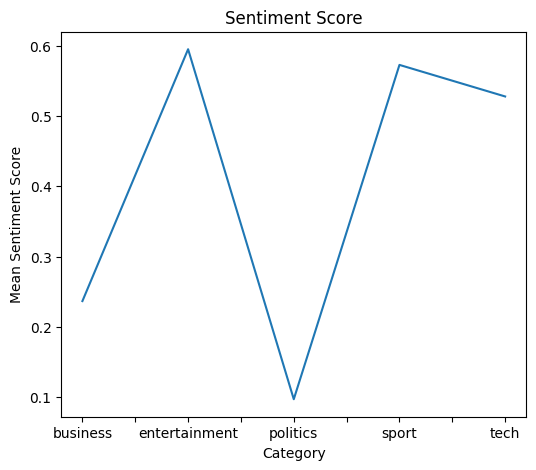

In [17]:
#generate mean of sentiment_score by period
dfg = df_output.groupby(['category'])['sentiment_score'].mean()
dfg.index = dfg.index.astype(str).str.replace(r'\.0$', '', regex=True)
#create a bar plot
dfg.plot(kind='line', title='Sentiment Score', ylabel='Mean Sentiment Score',
         xlabel='Category', figsize=(6, 5))

This line plot shows the mean sentiment score across all categories.

- Entertainment has the most positive sentiments
- Politics has the lowest sentiments
- Every category on average is positive


([0, 1, 2, 3, 4],
 [Text(0, 0, 'business'),
  Text(1, 0, 'entertainment'),
  Text(2, 0, 'politics'),
  Text(3, 0, 'sport'),
  Text(4, 0, 'tech')])

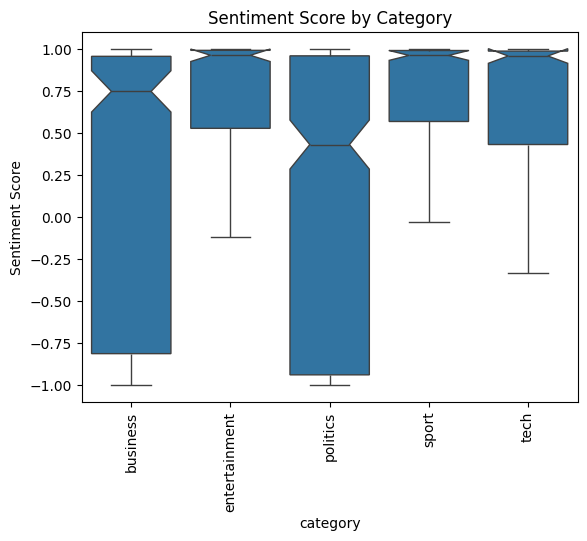

In [19]:
import seaborn as sns
#create seaborn boxplots by group
sns.boxplot(x='category', y='sentiment_score', notch = True,
            data=df_output, showfliers=False).set(title='Sentiment Score by Category')
#modify axis labels
plt.xlabel('category')
plt.ylabel('Sentiment Score')
plt.xticks(rotation=90)

The boxplots show the distribution of sentiment score across all categories.

- Sports does not have even one negative sentiment
- Politics and Business have lower medians
- Politics has the lowest median
- Each category has at least one sentiment score of +1.000




## ✅ **TASK 2 [2 Points]: At the end of your Colab notebook, create a new text cell, and write a brief reflection for this assignment in a few sentences addressing the following:**

**What went well? What did not go well, or what challenges did you encounter?**   
What went well in this assignment was the ease of moving from each step and my comprehension skills. Because of the way the sample colab file was written, I was able to understand things easily. For example, the description of the polarity scores helped make the information stick better, compared to what was given in the readings this week. The background information helped my overall comprehension skills as I moved through the lab. In terms of some challenges I encountered, I only encountered one; when I was importing my data. The sample code had comma seperations, but my data was seperated by tabs. I had to go back to lab-4 to realize and fix my mistake.

**In what ways could sentiment analysis be integrated into your current or future professional or research work?**   
Two ways that sentiment analysis could be integrated into my future professional or research work is potentially during my time in graduate school. I could be asked to analyze the overall sentiments of articles like I did in this assignment. I could also, when developing my dissertation, decide to incorporate this analysis to strengthen my argument. Other than my future life in a graduate school setting though, I do not forsee this analysis being used at all.